In [1]:
import sys
sys.path.append('../')

In [2]:
import os, yaml, nibabel as nib, argparse
import matplotlib.pyplot as plt

from monai.inferers import sliding_window_inference

import torch

from codes.model.attentiondenseunet import AttentionDenseUNet
from codes.trainer import SRGANTrainer, define_trainer
from codes.data_utils import define_dataloaders, define_trans

/home/juhha/anaconda3/envs/juhha/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/juhha/anaconda3/envs/juhha/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:
device = 'cuda:7'

In [17]:
import json
meta = json.load(open('../data/meta/brats21.json'))

In [18]:
len(meta['files'])

1251

# HCP1200

/home/juhha/anaconda3/envs/juhha/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


t1 t2


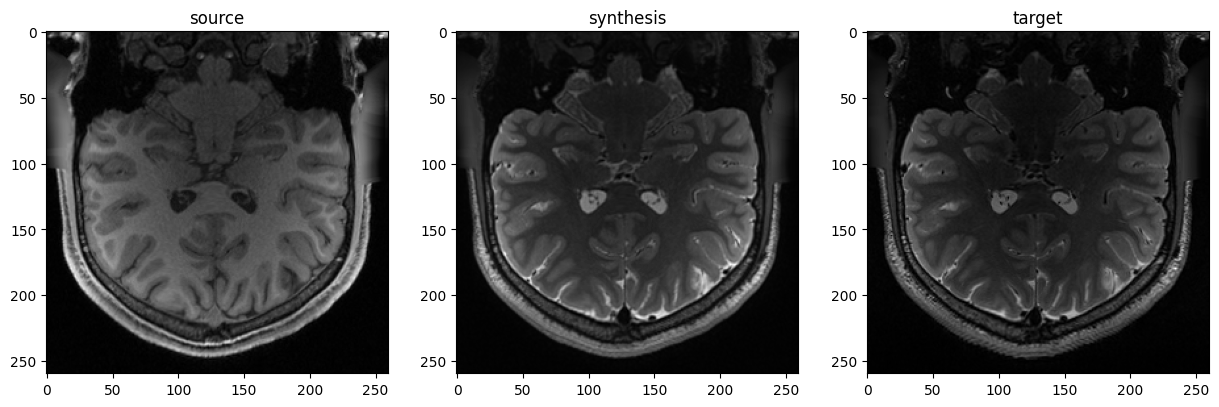

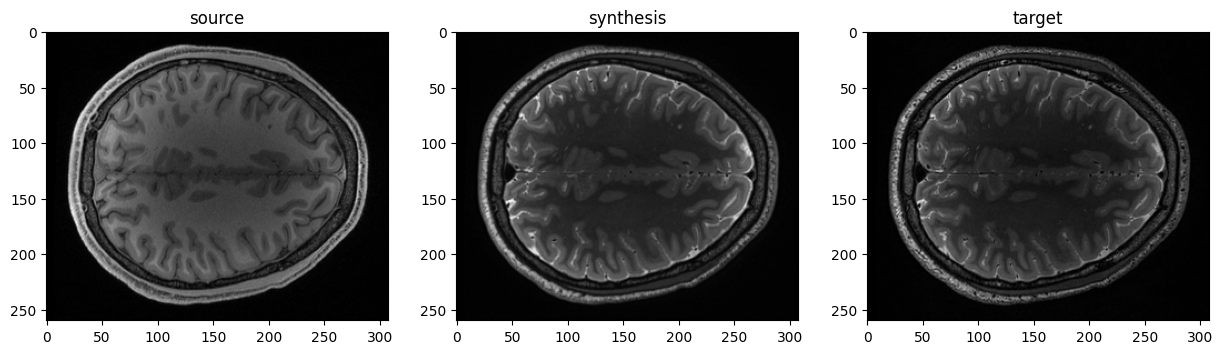

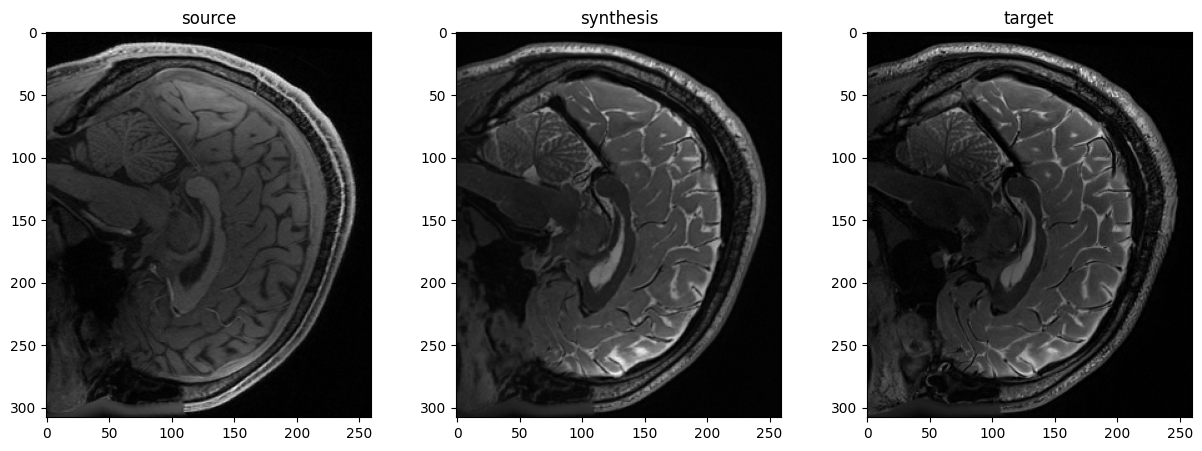

In [4]:
# Load configuration
config = yaml.safe_load(open('../options/hcp1200_t1tot2.yaml'))
config['checkpoint'] = '../checkpoint/hcp1200_t1tot2/fold_0'
args = argparse.Namespace()
args.device = device
args.fold = 0
# Load transform function
_, _, trans = define_trans(config)
# Load data
source_key = config['train_opt']['source_key']
target_key = config['train_opt']['target_key']
print(source_key, target_key)
data = trans({'t1': '../data/samples/hcp1200/t1.nii.gz', 't2': '../data/samples/hcp1200/t2.nii.gz'})
source = data[source_key]
target = data[target_key]
# load trainer
trainer = define_trainer(args, config)
# predict
pred = trainer.predict(source.unsqueeze(0).to(device), sliding_inference=True)
# Visualize
source = source[0]
pred = pred[0,0]
target = target[0]
for i in range(3):
    source = source.permute(1,2,0)
    target = target.permute(1,2,0)
    pred = pred.permute(1,2,0)
    
    slice_idx = source.shape[-1]//2
    fig, axes = plt.subplots(1,3,figsize = (15,5))
    axes[0].imshow(source.cpu()[slice_idx], cmap = 'gray'); axes[0].set_title('source')
    axes[1].imshow(pred.cpu()[slice_idx], cmap = 'gray'); axes[1].set_title('synthesis')
    axes[2].imshow(target.cpu()[slice_idx], cmap = 'gray'); axes[2].set_title('target')
    plt.show()

In [9]:
import numpy as np
num_params = 0
for p in trainer.net_g.parameters():
    num_params += np.prod(p.shape)
print(f'{num_params:,}')

6,176,846


In [10]:
import numpy as np
num_params = 0
for p in trainer.net_d.parameters():
    num_params += np.prod(p.shape)
print(f'{num_params:,}')

578,364


# dHCP

/home/juhha/anaconda3/envs/juhha/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


t2 t1


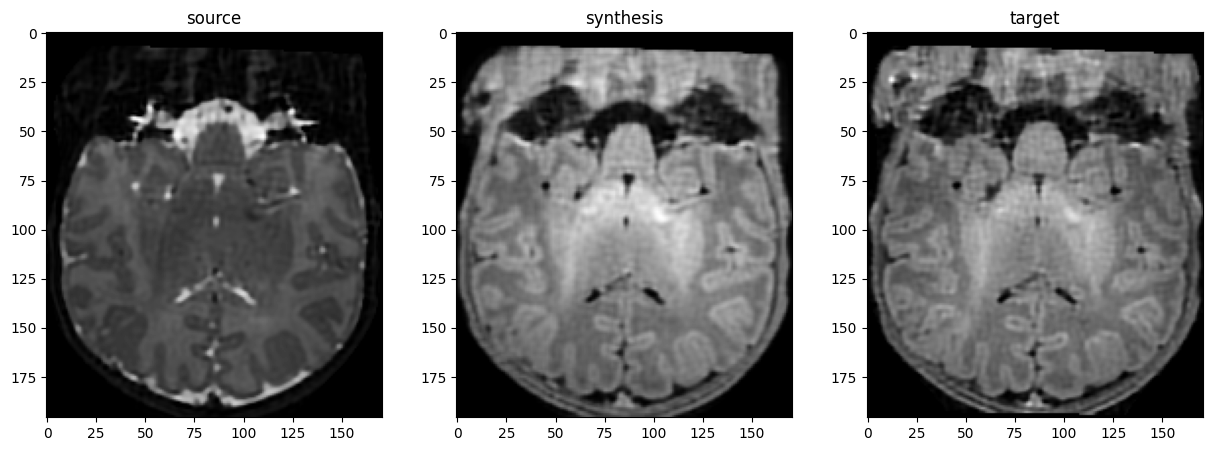

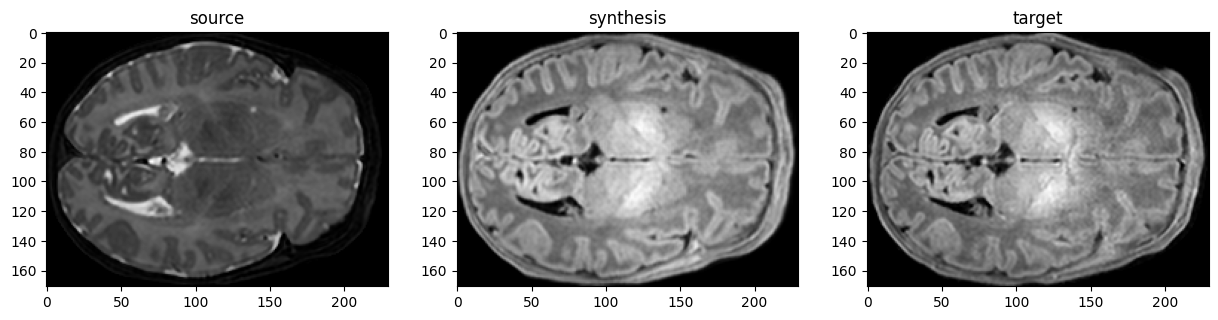

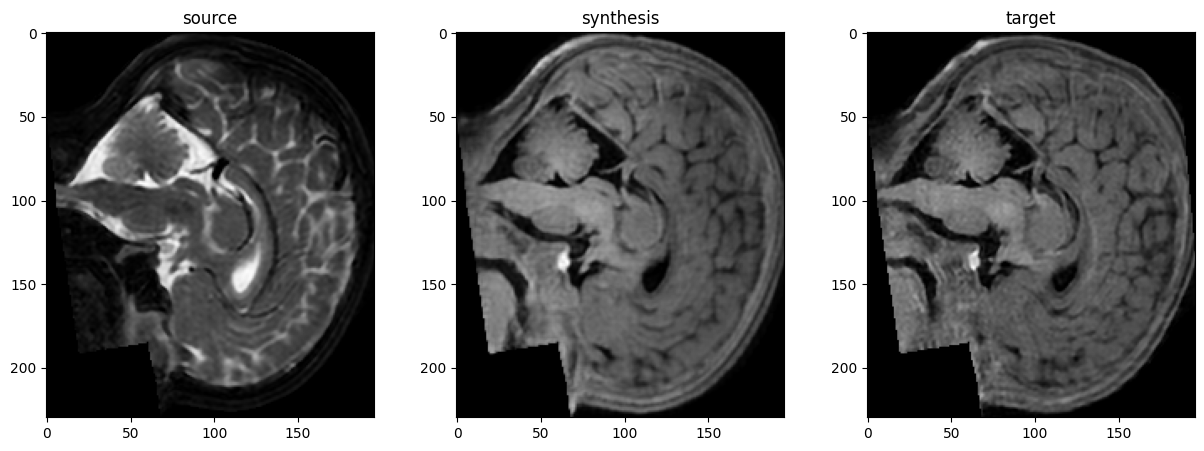

In [5]:
# Load configuration
config = yaml.safe_load(open('../options/dhcp_t2tot1.yaml'))
config['checkpoint'] = '../checkpoint/dhcp_t2tot1/fold_0/'
args = argparse.Namespace()
args.device = device
args.fold = 0
# Load transform function
_, _, trans = define_trans(config)
# Load data
source_key = config['train_opt']['source_key']
target_key = config['train_opt']['target_key']
print(source_key, target_key)
data = trans({'t1': '../data/samples/dhcp/t1.nii.gz', 't2': '../data/samples/dhcp/t2.nii.gz'})
source = data[source_key]
target = data[target_key]
# load trainer
trainer = define_trainer(args, config)
# predict
pred = trainer.predict(source.unsqueeze(0).to(device), sliding_inference=True)
# Visualize
source = source[0]
pred = pred[0,0]
target = target[0]
for i in range(3):
    source = source.permute(1,2,0)
    target = target.permute(1,2,0)
    pred = pred.permute(1,2,0)
    
    slice_idx = source.shape[0]//2
    fig, axes = plt.subplots(1,3,figsize = (15,5))
    axes[0].imshow(source.cpu()[slice_idx], cmap = 'gray'); axes[0].set_title('source')
    axes[1].imshow(pred.cpu()[slice_idx], cmap = 'gray'); axes[1].set_title('synthesis')
    axes[2].imshow(target.cpu()[slice_idx], cmap = 'gray'); axes[2].set_title('target')
    plt.show()

# BraTS

/home/juhha/anaconda3/envs/juhha/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


t2 flair


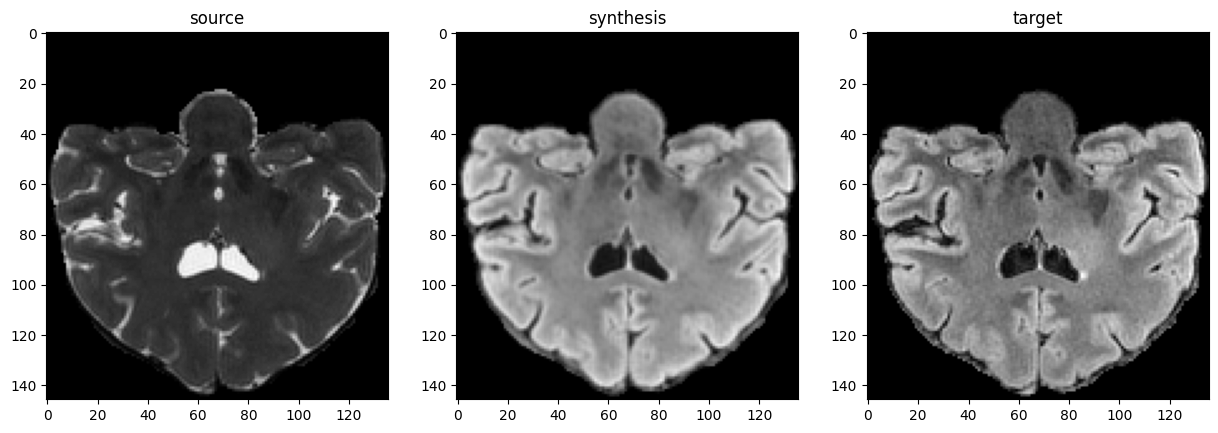

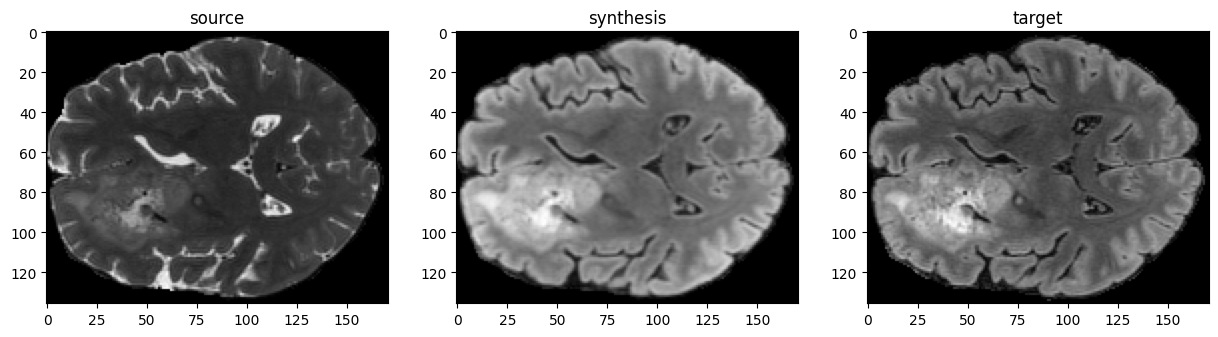

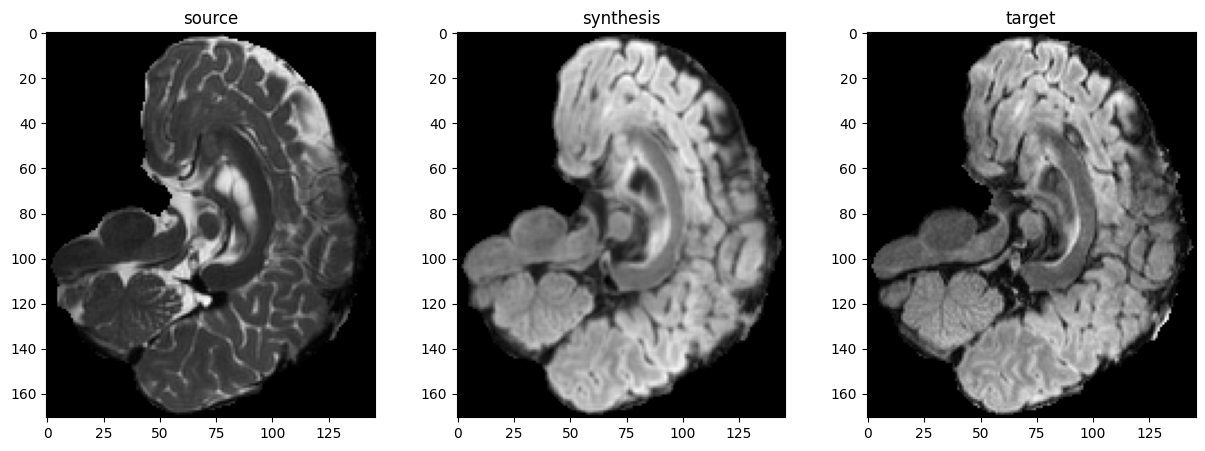

In [6]:
# Load configuration
config = yaml.safe_load(open('../options/brats_t2toflair.yaml'))
# config['checkpoint'] = '../../checkpoint/attdenseunet_brats_t2toflair_nearest/fold_0/'
config['checkpoint'] = '../checkpoint/brats_t2toflair/fold_0/'
args = argparse.Namespace()
args.device = device
args.fold = 0
# Load transform function
_, _, trans = define_trans(config)
# Load data
source_key = config['train_opt']['source_key']
target_key = config['train_opt']['target_key']
print(source_key, target_key)
data = trans({'flair': '../data/samples/brats/flair.nii.gz', 't2': '../data/samples/brats/t2.nii.gz'})
source = data[source_key]
target = data[target_key]
# load trainer
trainer = define_trainer(args, config)
# predict
pred = trainer.predict(source.unsqueeze(0).to(device), sliding_inference=True)
# Visualize
source = source[0]
pred = pred[0,0]
target = target[0]
for i in range(3):
    source = source.permute(1,2,0)
    target = target.permute(1,2,0)
    pred = pred.permute(1,2,0)
    
    slice_idx = source.shape[0]//2
    fig, axes = plt.subplots(1,3,figsize = (15,5))
    axes[0].imshow(source.cpu()[slice_idx], cmap = 'gray'); axes[0].set_title('source')
    axes[1].imshow(pred.cpu()[slice_idx], cmap = 'gray'); axes[1].set_title('synthesis')
    axes[2].imshow(target.cpu()[slice_idx], cmap = 'gray'); axes[2].set_title('target')
    plt.show()

# SynthRAD2023 - MR to CT

/home/juhha/anaconda3/envs/juhha/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


mr ct


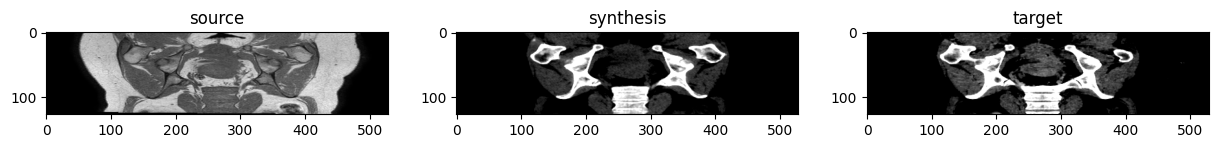

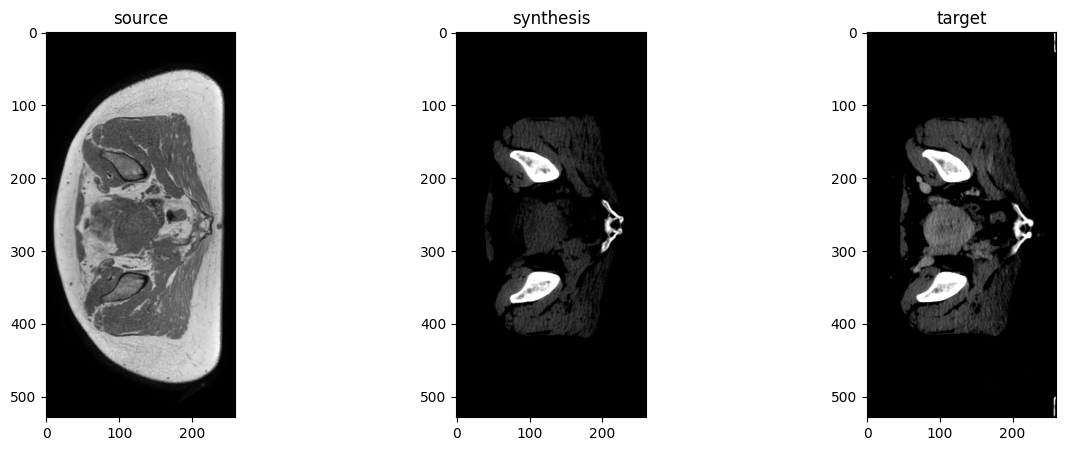

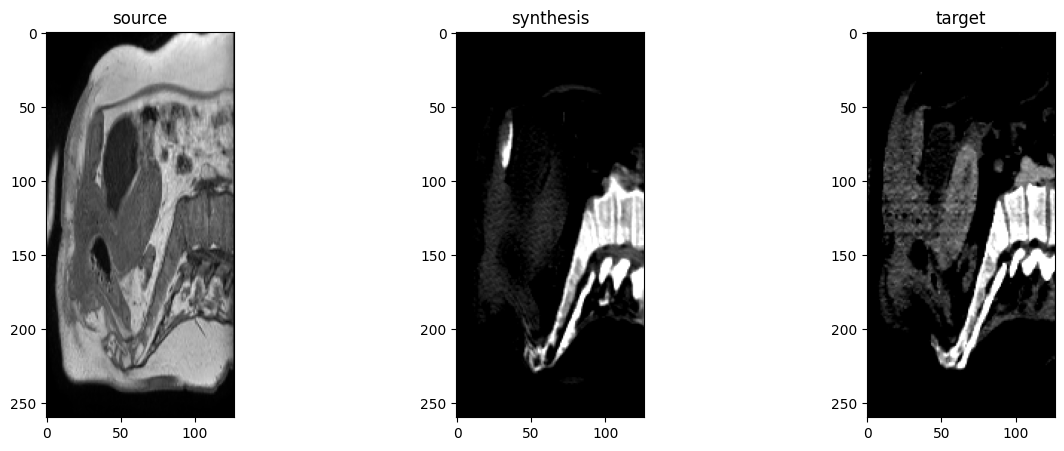

In [7]:
# Load configuration
config = yaml.safe_load(open('../options/synth_t1toct.yaml'))
config['checkpoint'] = '../checkpoint/synth_t1toct/fold_0/'
args = argparse.Namespace()
args.device = device
args.fold = 0
# Load transform function
_, _, trans = define_trans(config)
# Load data
source_key = config['train_opt']['source_key']
target_key = config['train_opt']['target_key']
print(source_key, target_key)
data = trans({'mr': '../data/samples/synth_t1toct/t1.nii.gz', 'ct': '../data/samples/synth_t1toct/ct.nii.gz', 'mask': '../data/samples/synth_t1toct/mask.nii.gz'}) # SynthRAD2023 offer mask for foreground
source = data[source_key]
target = data[target_key]
# load trainer
trainer = define_trainer(args, config)
# predict
pred = trainer.predict(source.unsqueeze(0).to(device), sliding_inference=True)
# Visualize
minval = 1024/4024 # clip value to highlight organ and bone
maxval = (1024+250)/4024
source = source[0]
pred = pred[0,0]
target = target[0]
for i in range(3):
    source = source.permute(1,2,0)
    target = target.permute(1,2,0)
    pred = pred.permute(1,2,0)
    
    slice_idx = source.shape[0]//2
    fig, axes = plt.subplots(1,3,figsize = (15,5))
    axes[0].imshow(source.cpu()[slice_idx], cmap = 'gray'); axes[0].set_title('source')
    axes[1].imshow(pred.cpu()[slice_idx].clip(minval, maxval), cmap = 'gray'); axes[1].set_title('synthesis')
    axes[2].imshow(target.cpu()[slice_idx].clip(minval, maxval), cmap = 'gray'); axes[2].set_title('target')
    plt.show()

# SynthRAD2023 - CBCT to CT

/home/juhha/anaconda3/envs/juhha/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


cbct ct


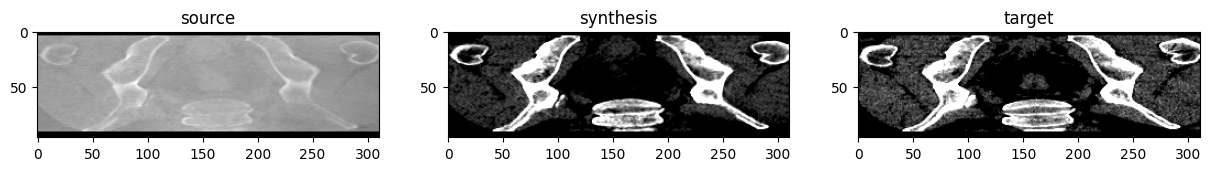

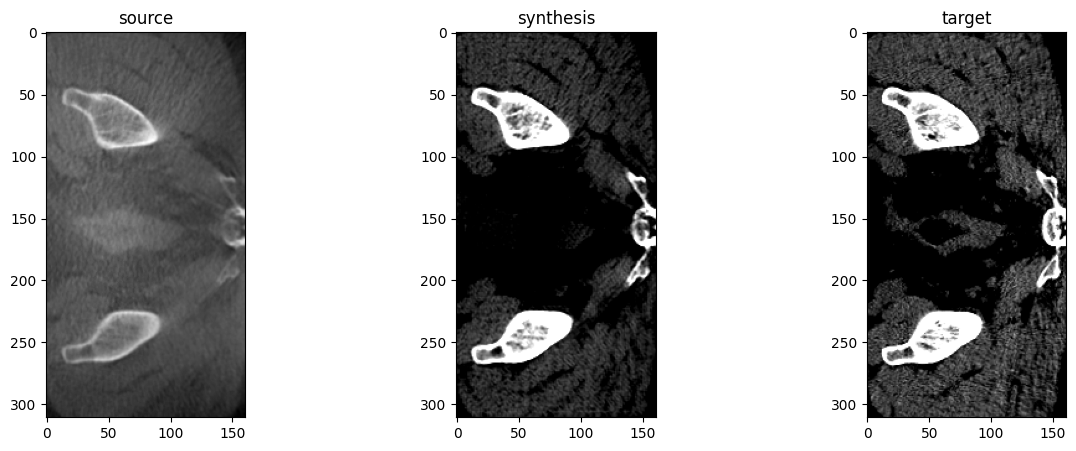

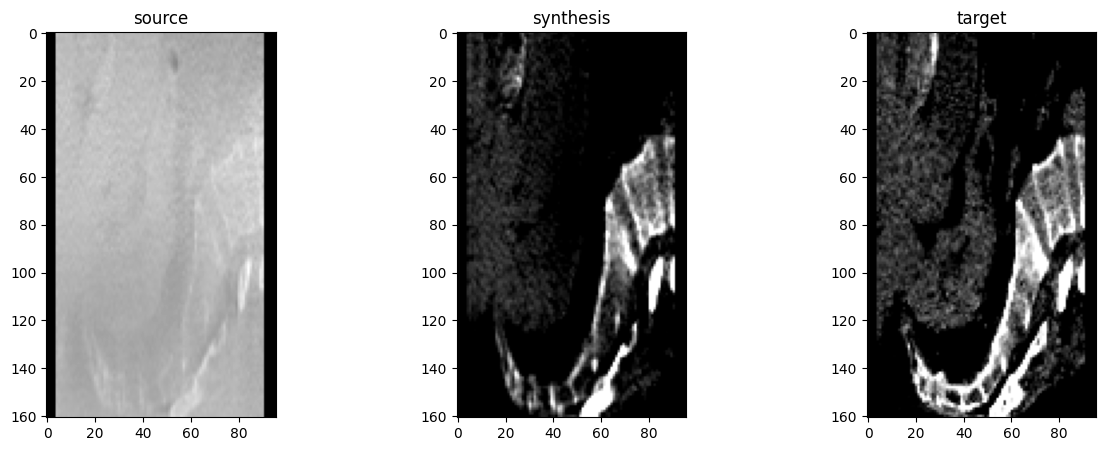

In [8]:
# Load configuration
config = yaml.safe_load(open('../options/synth_cbcttoct.yaml'))
config['checkpoint'] = '../checkpoint/synth_cbcttoct/fold_0/'
args = argparse.Namespace()
args.device = device
args.fold = 0
# Load transform function
_, _, trans = define_trans(config)
# Load data
source_key = config['train_opt']['source_key']
target_key = config['train_opt']['target_key']
print(source_key, target_key)
data = trans({'cbct': '../data/samples/synth_cbcttoct/cbct.nii.gz', 'ct': '../data/samples/synth_cbcttoct/ct.nii.gz', 'mask': '../data/samples/synth_cbcttoct/mask.nii.gz'}) # SynthRAD2023 offer mask for foreground
source = data[source_key]
target = data[target_key]
# load trainer
trainer = define_trainer(args, config)
# predict
pred = trainer.predict(source.unsqueeze(0).to(device), sliding_inference=True)
# Visualize
minval = 1024/4024 # clip value to highlight organ and bone
maxval = (1024+250)/4024
source = source[0]
pred = pred[0,0]
target = target[0]
for i in range(3):
    source = source.permute(1,2,0)
    target = target.permute(1,2,0)
    pred = pred.permute(1,2,0)
    
    slice_idx = source.shape[0]//2
    fig, axes = plt.subplots(1,3,figsize = (15,5))
    axes[0].imshow(source.cpu()[slice_idx], cmap = 'gray'); axes[0].set_title('source')
    axes[1].imshow(pred.cpu()[slice_idx].clip(minval, maxval), cmap = 'gray'); axes[1].set_title('synthesis')
    axes[2].imshow(target.cpu()[slice_idx].clip(minval, maxval), cmap = 'gray'); axes[2].set_title('target')
    plt.show()